# Missing data patterns

Real time series arrive with gaps — sensor outages, weekend reporting holidays, dropped records. SynForecast injects missing values so you can test imputation and check that a model tolerates gaps rather than silently mishandling them. Three patterns cover the common shapes.

::: {.callout-tip}
## Choosing a pattern

- `"random"` — points drop independently (transient dropouts).
- `"block"` — contiguous runs go missing (outages); set `missing_block_size`.
- `"seasonal"` — gaps recur on a cycle (e.g. weekends); set `missing_seasonal_period`.

`missing_rate` is the target fraction missing. Missing values appear as `NaN` in `y`; the plots below mark them with red ticks along the bottom.
:::

In [ ]:
import matplotlib.pyplot as plt
import polars as pl

from synforecast.generators import RandomWalkGenerator, SeasonalGenerator


def plot_missing(df, title):
    """Plot each series (gaps where missing) and rug-mark missing timestamps."""
    fig, ax = plt.subplots(figsize=(11, 4))
    for uid in df["unique_id"].unique(maintain_order=True).to_list():
        s = df.filter(pl.col("unique_id") == uid).sort("ds")
        ax.plot(s["ds"], s["y"], linewidth=1, alpha=0.85, label=str(uid))
    missing = df.filter(pl.col("y").is_nan())
    if missing.height:
        y0 = df["y"].min()
        ax.scatter(missing["ds"], [y0] * missing.height, marker="|",
                   color="crimson", s=40, label="missing")
    ax.set(title=title, xlabel="ds", ylabel="y")
    ax.legend(fontsize=8)
    plt.tight_layout()
    plt.show()


def missing_rate(df):
    return df["y"].is_nan().mean()

## Random gaps

Independent dropouts scattered through the series — the simplest pattern, and a reasonable default for unreliable feeds.

target rate 15%, actual 15.0%


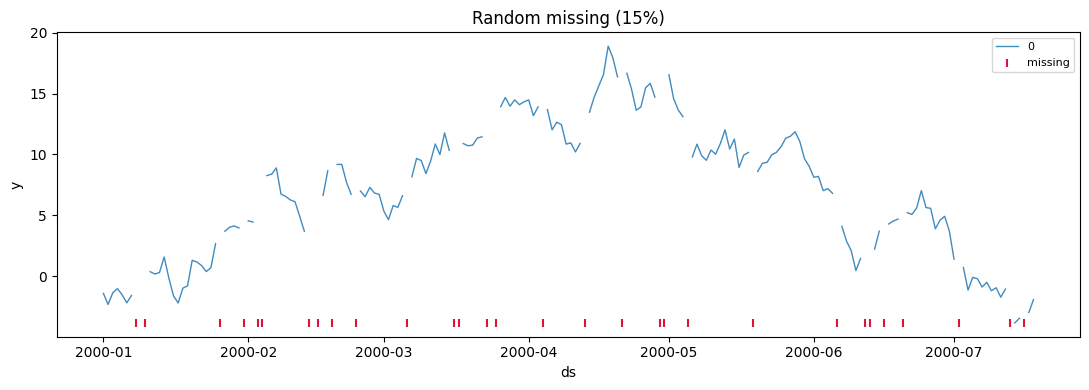

In [ ]:
random_df = RandomWalkGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    missing_data=True,
    missing_pattern="random",
    missing_rate=0.15,
    seed=42,
).generate(n_series=1)
print(f"target rate 15%, actual {missing_rate(random_df):.1%}")
plot_missing(random_df, "Random missing (15%)")

## Block gaps (outages)

Real outages remove *consecutive* observations. `missing_block_size` sets the typical run length, so the same overall rate now arrives in a few long stretches instead of many isolated points.

target rate 20%, actual 20.0%, block size 5


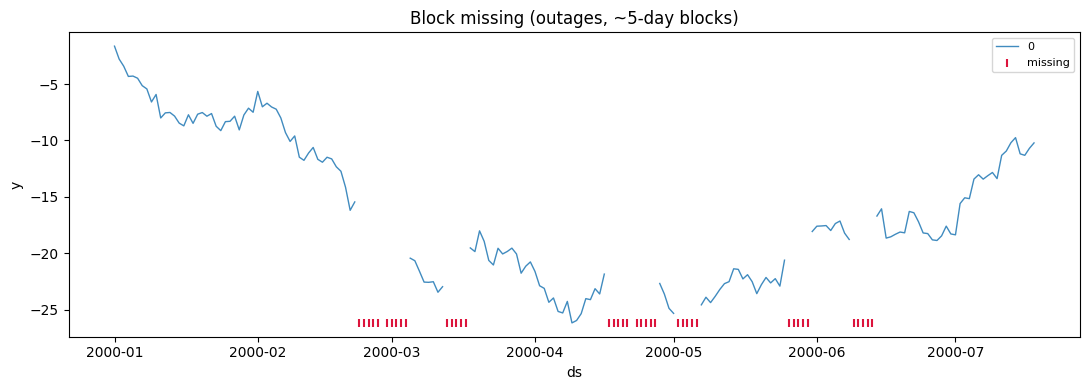

In [ ]:
block_df = RandomWalkGenerator(
    engine="polars",
    min_length=200,
    max_length=200,
    freq="D",
    missing_data=True,
    missing_pattern="block",
    missing_rate=0.2,
    missing_block_size=5,
    seed=123,
).generate(n_series=1)
print(f"target rate 20%, actual {missing_rate(block_df):.1%}, block size 5")
plot_missing(block_df, "Block missing (outages, ~5-day blocks)")

## Seasonal gaps (recurring holidays)

With `missing_pattern="seasonal"` gaps recur on a fixed cycle — the classic weekend-reporting gap on daily data (`missing_seasonal_period=7`).

target rate 12%, actual 10.2%


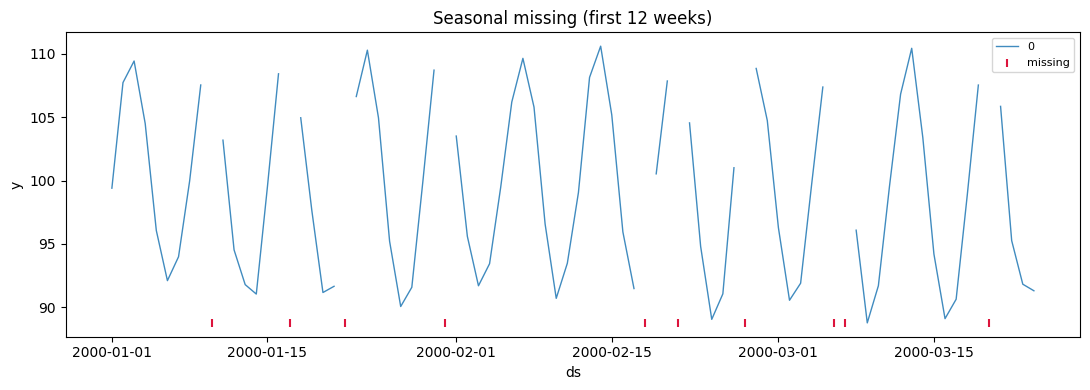

In [ ]:
seasonal_df = SeasonalGenerator(
    engine="polars",
    min_length=364,
    max_length=364,
    freq="D",
    seasonality_period=7,
    seasonality_amplitude=10.0,
    base_level=100.0,
    missing_data=True,
    missing_pattern="seasonal",
    missing_rate=0.12,
    missing_seasonal_period=7,
    seed=456,
).generate(n_series=1)
print(f"target rate 12%, actual {missing_rate(seasonal_df):.1%}")
plot_missing(seasonal_df.head(84), "Seasonal missing (first 12 weeks)")

The gaps concentrate on particular days of the week rather than spreading evenly — the breakdown below makes that concrete.

In [ ]:
(
    seasonal_df.with_columns(
        (pl.col("ds").dt.weekday()).alias("weekday"),
        pl.col("y").is_nan().alias("is_missing"),
    )
    .group_by("weekday")
    .agg((pl.col("is_missing").mean() * 100).round(1).alias("missing_pct"))
    .sort("weekday")
)

weekday,missing_pct
i8,f64
1,26.9
2,9.6
3,7.7
4,0.0
5,5.8
6,7.7
7,13.5


## Rate and multiple series

`missing_rate` scales the amount missing, and each series in a panel gets its own independent gaps.

In [ ]:
for rate in (0.05, 0.15, 0.30):
    df = RandomWalkGenerator(
        engine="polars", min_length=300, max_length=300, freq="D",
        missing_data=True, missing_pattern="random", missing_rate=rate, seed=789,
    ).generate(n_series=1)
    print(f"target {rate:>4.0%}  ->  actual {missing_rate(df):.1%}")

multi_df = RandomWalkGenerator(
    engine="polars", min_length=100, max_length=100, freq="D",
    missing_data=True, missing_pattern="random", missing_rate=0.2, seed=1234,
).generate(n_series=3)
print("\nper-series missing rate:")
print(
    multi_df.group_by("unique_id")
    .agg((pl.col("y").is_nan().mean() * 100).round(1).alias("missing_pct"))
    .sort("unique_id")
)

target   5%  ->  actual 5.0%
target  15%  ->  actual 15.0%
target  30%  ->  actual 30.0%

per-series missing rate:
shape: (3, 2)
┌───────────┬─────────────┐
│ unique_id ┆ missing_pct │
│ ---       ┆ ---         │
│ cat       ┆ f64         │
╞═══════════╪═════════════╡
│ 0         ┆ 20.0        │
│ 1         ┆ 20.0        │
│ 2         ┆ 20.0        │
└───────────┴─────────────┘


::: {.callout-note}
## Related capabilities

- [Multivariate missingness](multivariate_missingness) — coordinated gaps across channels (e.g. a whole sensor dropping out).
- [Anomalies](anomalies) and [changepoints](changepoints) compose with missing data for realistic test series.
:::